<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:
# Add code here 🔧
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaned Denver listings exported at the end of Assignment 6 (uploaded to the Colab session)
df = pd.read_csv("/content/cleaned_airbnb_data_6.csv")

print(df.shape)
df.head()


(4939, 74)


,id,listing_url,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_reviews
0,360,https://www.airbnb.com/rooms/360,2026-06-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,https://a0.muscache.com/pictures/monet/Select-...,666,https://www.airbnb.com/users/show/666,1462506156295946552,...,4.99,4.98,4.90,2017-BFN-0002177,1,1,0,0,1.94,True
1,364,https://www.airbnb.com/rooms/364,2026-07-02,previous scrape,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of ...",https://a0.muscache.com/pictures/11766413/a2c5...,783,https://www.airbnb.com/users/show/783,1462506164263986177,...,4.96,4.65,4.71,NaN,1,1,0,0,0.42,True
2,592,https://www.airbnb.com/rooms/592,2026-06-30,city scrape,private,This room is in the basement. It does not hav...,https://a0.muscache.com/pictures/ba522ff9-84c9...,933,https://www.airbnb.com/users/show/933,1462506173520460203,...,4.96,4.84,4.88,2021-BFN-0000578,1,0,1,0,1.05,True
3,686,https://www.airbnb.com/rooms/686,2026-06-30,city scrape,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG...,https://a0.muscache.com/pictures/108112/e6d5d3...,990,https://www.airbnb.com/users/show/990,1462506177119173037,...,4.91,4.87,4.82,NaN,1,0,1,0,1.16,True
4,1940,https://www.airbnb.com/rooms/1940,2026-06-30,city scrape,"Baker Studio Pet-friendly, Walkable, Patio",Private studio retreat in a charming historic ...,https://a0.muscache.com/pictures/miso/Hosting-...,2150,https://www.airbnb.com/users/show/2150,1462506289316853263,...,4.99,4.90,4.90,2018-BFN-0002596,2,2,0,0,2.42,True


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

Skewness of price: 59.3
count      4251.00
mean        276.04
std        1753.13
min           7.38
25%         106.00
50%         176.45
75%         291.00
max      110616.60
Name: price, dtype: float64


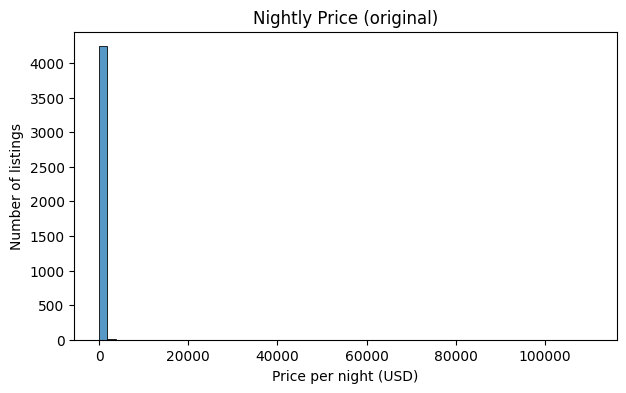

Skewness of log(price): 0.28


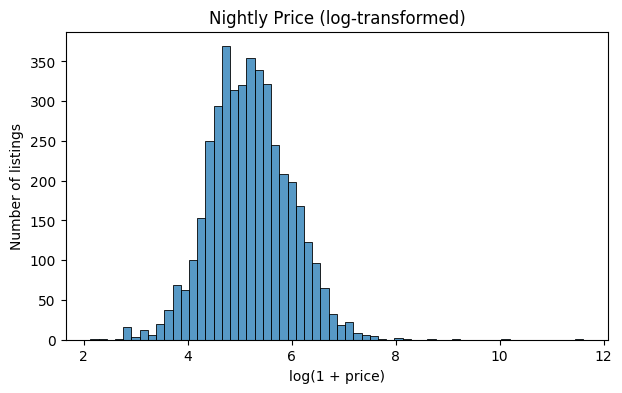

In [2]:
# Add code here 🔧
# Column: price (nightly price in USD)
print("Skewness of price:", round(df['price'].skew(), 2))
print(df['price'].describe().round(2))

# Histogram before transforming
plt.figure(figsize=(7, 4))
sns.histplot(df['price'].dropna(), bins=60)
plt.title("Nightly Price (original)")
plt.xlabel("Price per night (USD)")
plt.ylabel("Number of listings")
plt.show()

# Log transform: log(1 + price) pulls in the long right tail
df['price_log'] = np.log1p(df['price'])
print("Skewness of log(price):", round(df['price_log'].skew(), 2))

# Histogram after transforming
plt.figure(figsize=(7, 4))
sns.histplot(df['price_log'].dropna(), bins=60)
plt.title("Nightly Price (log-transformed)")
plt.xlabel("log(1 + price)")
plt.ylabel("Number of listings")
plt.show()


### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧
1. I examined `price`, the nightly price for the 4,251 Denver listings that have one. It's extremely right-skewed (skewness 59.3). The median is about ＄176 a night, but a few listings are priced in the thousands, up to ＄110,617.

2. I used a log transformation, `np.log1p(price)`, which is log(1 + price). A log compresses large values much more than small ones, so the long right tail gets pulled in while the order of the prices stays the same. Adding 1 avoids problems with a log of 0.

3. After the transform, skewness dropped from 59.3 to 0.28, so the distribution is close to symmetric. The original histogram is basically one tall bar with a long empty tail. The log version shows the real spread of typical Denver prices, so a stakeholder can see where most listings fall. It also makes price much better behaved for averages and for the regression model later in the course, because a few extreme listings won't dominate the results.


## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print(df[['availability_365', 'number_of_reviews']].describe().round(2))

# Min-Max scale: availability_365 (0 to 365 days) -> 0 to 1
mm = MinMaxScaler()
df['availability_365_minmax'] = mm.fit_transform(df[['availability_365']])

# Z-score scale: number_of_reviews (0 to about 1,800) -> mean 0, standard deviation 1
zs = StandardScaler()
df['number_of_reviews_z'] = zs.fit_transform(df[['number_of_reviews']])

# Compare the new columns with the originals
df[['availability_365', 'availability_365_minmax',
    'number_of_reviews', 'number_of_reviews_z']].describe().round(3)


       availability_365  number_of_reviews
count           4939.00            4939.00
mean             206.18              71.81
std              122.69             125.81
min                0.00               0.00
25%               90.00               3.00
50%              235.00              21.00
75%              320.00              85.00
max              365.00            1798.00


,availability_365,availability_365_minmax,number_of_reviews,number_of_reviews_z
count,4939.000,4939.000,4939.000,4939.000
mean,206.178,0.565,71.805,-0.000
std,122.693,0.336,125.811,1.000
min,0.000,0.000,0.000,-0.571
25%,90.000,0.247,3.000,-0.547
50%,235.000,0.644,21.000,-0.404
75%,320.000,0.877,85.000,0.105
max,365.000,1.000,1798.000,13.722



### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧
1. I used **Min-Max scaling** on `availability_365` (originally 0–365 days), which now runs from 0 to 1 with a median of 0.64. I used **Z-score standardization** on `number_of_reviews` (originally 0–1,798), which now has a mean of 0 and a standard deviation of 1. The median is −0.40, which means most listings have fewer reviews than average. A few very popular listings sit far above, up to 13.7 standard deviations.

2. Scaled values are more useful when comparing or combining columns that are measured in different units, like days available vs. review counts. They also matter for models that use distance or weights (k-nearest neighbors, clustering, regression with regularization), because the column with the bigger numbers would otherwise dominate. Z-scores also make it easy to spot unusual listings, since anything above about 2 is well above typical.

3. Airbnb's data science and pricing teams would benefit most. They could combine availability and review volume into a single "listing activity" or ranking score without one column overpowering the other. A host success team could also use review z-scores to find standout listings (high positive scores) or listings that need help getting booked (near the minimum).


## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

count    4939.0
mean       12.7
std        18.8
min         0.0
25%         0.0
50%         3.0
75%        20.0
max       224.0
Name: number_of_reviews_ltm, dtype: float64
review_activity
Low       1886
Medium    1429
High      1624
Name: count, dtype: int64


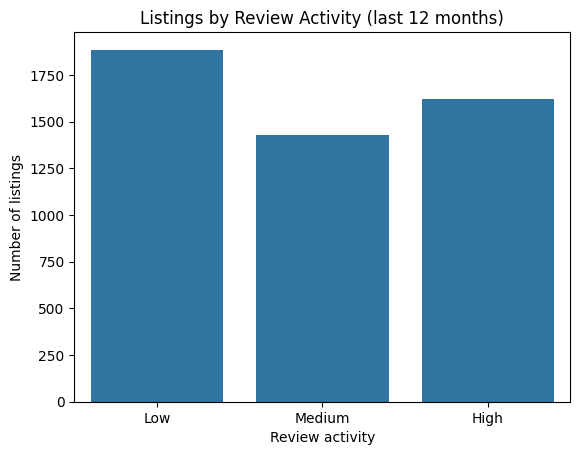

In [4]:
# Add code here 🔧
# Column: number_of_reviews_ltm (reviews in the last 12 months), a measure of recent booking activity
print(df['number_of_reviews_ltm'].describe().round(1))

# 3 bins with business-friendly cutoffs:
#   Low    = 0-1 reviews in the past year (little or no recent activity)
#   Medium = 2-12 reviews (roughly up to one a month)
#   High   = 13+ reviews (more than one a month)
df['review_activity'] = pd.cut(df['number_of_reviews_ltm'],
                               bins=[-1, 1, 12, np.inf],
                               labels=['Low', 'Medium', 'High'])

print(df['review_activity'].value_counts().sort_index())

sns.countplot(data=df, x='review_activity', order=['Low', 'Medium', 'High'])
plt.title("Listings by Review Activity (last 12 months)")
plt.xlabel("Review activity")
plt.ylabel("Number of listings")
plt.show()


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧
1. I grouped `number_of_reviews_ltm` (reviews in the last 12 months) into **3 categories** in a new `review_activity` column: **Low** (0–1 reviews, 1,886 listings), **Medium** (2–12 reviews, 1,429 listings) and **High** (13 or more, 1,624 listings). I chose cutoffs that mean something to a business reader: almost no recent stays, up to about one review a month, and more than one a month. They also split the listings into three similarly sized groups.

2. Raw review counts range from 0 to 224 and are heavily skewed, which is hard to act on. Three labeled groups are easier to read in a report, can be filtered in a dashboard, and are simple to use for segmenting. People can make decisions without debating whether 11 vs. 14 reviews is meaningful.

3. This would help the **marketing team** target campaigns: "Low" listings could get tips or promotions to get their first bookings, and "High" listings could be featured or used as examples. It would also help **host support** prioritize outreach, and lets **city partners** see how many listings are actually active vs. listed but rarely booked.


## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [5]:
# Add code here 🔧

# 1. Ratio: price per guest = nightly price / number of guests the listing holds
df['price_per_guest'] = df['price'] / df['accommodates']
print(df['price_per_guest'].describe().round(2))

# 2. Flag: long-term listing = minimum stay of 30 nights or more
df['long_term_stay'] = (df['minimum_nights'] >= 30).astype(int)
print("\nLong-term listings (30+ night minimum):", df['long_term_stay'].sum(),
      f"({df['long_term_stay'].mean():.1%} of listings)")

# Quick check of how the two groups differ
display(df.groupby('long_term_stay')[['price', 'price_per_guest', 'availability_365']].median().round(2))


count     4251.00
mean        76.99
std        855.07
min          2.68
25%         35.40
50%         52.04
75%         77.15
max      55308.30
Name: price_per_guest, dtype: float64

Long-term listings (30+ night minimum): 1121 (22.7% of listings)


,price,price_per_guest,availability_365
long_term_stay,,,
0,209.79,57.85,230.0
1,100.63,35.51,246.0


### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧
1. I created `price_per_guest` (price ÷ accommodates) and `long_term_stay` (1 if the minimum stay is 30 nights or more). Price per guest makes listings of different sizes comparable: a ＄300 home for 8 people is cheaper per person than a ＄150 studio for 2. The median is about ＄52 per guest per night. The long-term flag identifies listings aimed at monthly stays. That's 1,121 Denver listings (22.7%), which is a lot, and likely reflects Denver's rule that stays shorter than 30 nights need a short-term rental license.

2. **Guests and the platform** would use price per guest to compare value (for example, sorting search results for group trips). **Hosts and pricing analysts** would use it to benchmark their price against similar listings. The long-term flag would be used by **Airbnb's product and marketing teams**, which promote monthly stays, and by **city policy partners** who monitor short-term rentals.

3. Long-term listings are very different from short stays: their median price is about ＄101 a night vs. ＄210, and about ＄36 per guest vs. ＄58. Mixing them would make short-stay pricing look too low, so an analyst should separate them. A host deciding on a price can compare their price per guest with similar listings, instead of just the total nightly price.


## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [6]:
# Add code here 🔧
# room_type is nominal (no natural order), so use one-hot encoding
print(df['room_type'].value_counts())
print("Shape before:", df.shape)

room_dummies = pd.get_dummies(df['room_type'], prefix='room', dtype=int)
df = pd.concat([df, room_dummies], axis=1)   # keep the original room_type column for labels

print("Shape after:", df.shape)
df[['room_type'] + list(room_dummies.columns)].head()


room_type
Entire home/apt    4233
Private room        631
Shared room          52
Hotel room           23
Name: count, dtype: int64
Shape before: (4939, 80)
Shape after: (4939, 84)


,room_type,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room
0,Entire home/apt,1,0,0,0
1,Entire home/apt,1,0,0,0
2,Private room,0,0,1,0
3,Private room,0,0,1,0
4,Entire home/apt,1,0,0,0


### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧
1. I encoded `room_type`, which has four values: Entire home/apt (4,233 listings), Private room (631), Shared room (52) and Hotel room (23). Room type is one of the biggest drivers of price, but as text it can't go into a model.

2. I used **one-hot encoding** with `pd.get_dummies()`, because room types are nominal: there's no natural order between a hotel room and a private room. This added four 0/1 columns (`room_Entire home/apt`, `room_Hotel room`, `room_Private room`, `room_Shared room`), taking the data from 80 to 84 columns. I kept the original `room_type` column so reports can still show readable labels.

3. A pricing model can now learn a separate price effect for each room type. In a regression, one dummy is usually left out as the baseline (e.g., entire home), so each coefficient reads as "how much more or less than an entire home." For a dashboard or report, the 0/1 columns make it easy to calculate shares and averages by room type, such as the percent of listings that are entire homes (about 86% in Denver).


## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [7]:
# export csv here 🔧
# Drop link/image columns that won't be used in analysis or the Assignment 11 regression
url_cols = ['listing_url', 'picture_url', 'host_url', 'host_profile_url']
df = df.drop(columns=[c for c in url_cols if c in df.columns])

df.to_csv("cleaned_airbnb_data_7.csv", index=False)
print("Saved cleaned_airbnb_data_7.csv with shape", df.shape)


Saved cleaned_airbnb_data_7.csv with shape (4939, 80)


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The log transformation of price felt most important. One ＄110,617 listing and a handful of very expensive ones made the raw price nearly useless for averages or charts (skewness 59.3). After the log transform, the distribution was nearly symmetric (0.28), and suddenly the typical Denver price range was visible. It's a simple step that will make a big difference in the regression model in Assignment 11.

2. `price_per_guest` and the `long_term_stay` flag would be most useful. A **host** can benchmark their price per guest against similar listings. An **analyst** has to separate long-term listings (median ＄101/night) from short stays (＄210/night) to avoid misleading averages. A **city planner** can use the long-term flag and the `review_activity` groups to see how many listings are real short-term rentals that are actively booked.

3. I would build a Denver pricing dashboard with a neighborhood map colored by median price per guest, plus filters for room type, `review_activity` and short- vs. long-term stays. The next step would be a regression model predicting log price from room type, accommodates, neighborhood and reviews, so a host could see a suggested price range for their listing.

4. My learning outcomes focused on building Python skills and using AI to apply them to accounting and business decisions. This assignment practiced the Python transformations (log, scaling, binning, encoding) that make data ready for analysis, and I used AI to help write and check the code. Transforming skewed values and building ratios like price per guest is similar to the financial ratio analysis used in accounting, and turning raw records into decision-ready numbers is the skill I want to bring into my career.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"